In [1]:
import os
import copy
import json
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pennylane as qml
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("PennyLane version:", qml.__version__)
print("PyTorch version:", torch.__version__)

PennyLane version: 0.45.1
PyTorch version: 2.13.0+cpu


In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

torch.set_default_dtype(torch.float32)

print("Random seed:", RANDOM_STATE)

Random seed: 42


In [3]:
input_file = "quantum_encoded_healthcare_data.xlsx"

if not os.path.exists(input_file):
    raise FileNotFoundError(
        f"{input_file} was not found.\n"
        "Place the Day 15 output file in the notebook folder."
    )

X_train_df = pd.read_excel(
    input_file,
    sheet_name="X_Train_Quantum"
)

X_test_df = pd.read_excel(
    input_file,
    sheet_name="X_Test_Quantum"
)

y_train_df = pd.read_excel(
    input_file,
    sheet_name="Y_Train"
)

y_test_df = pd.read_excel(
    input_file,
    sheet_name="Y_Test"
)

class_mapping = pd.read_excel(
    input_file,
    sheet_name="Class_Mapping"
)

print("Training features:", X_train_df.shape)
print("Testing features:", X_test_df.shape)
print("Training target:", y_train_df.shape)
print("Testing target:", y_test_df.shape)

display(class_mapping.head())

Training features: (400, 4)
Testing features: (100, 4)
Training target: (400, 2)
Testing target: (100, 2)


,encoded_label,historical_medication_class
0,0,Acid-suppression class A
1,1,Acid-suppression class B
2,2,Antidiabetic class A
3,3,Antidiabetic class B
4,4,Antihistamine class A


In [4]:
target_column = "encoded_target"

if target_column not in y_train_df.columns:
    raise KeyError(
        f"'{target_column}' is missing from Y_Train. "
        f"Available columns: {y_train_df.columns.tolist()}"
    )

X_full_train = X_train_df.to_numpy(dtype=np.float32)
X_test = X_test_df.to_numpy(dtype=np.float32)

y_full_train = y_train_df[target_column].to_numpy(dtype=np.int64)
y_test = y_test_df[target_column].to_numpy(dtype=np.int64)

n_qubits = X_full_train.shape[1]
n_classes = len(np.unique(y_full_train))

print("Number of qubits:", n_qubits)
print("Number of classes:", n_classes)
print("Training angle range:",
      X_full_train.min(), "to", X_full_train.max())

assert n_qubits == 4, "This circuit was designed for four quantum features."
assert n_classes == 12, "Expected 12 medication classes."
assert not np.isnan(X_full_train).any()
assert not np.isnan(X_test).any()

Number of qubits: 4
Number of classes: 12
Training angle range: -3.1415927 to 3.1415927


In [5]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_full_train
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_validation.shape, y_validation.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (320, 4) (320,)
Validation set: (80, 4) (80,)
Test set: (100, 4) (100,)


In [6]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_validation_tensor = torch.tensor(
    X_validation,
    dtype=torch.float32
)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_validation_tensor = torch.tensor(
    y_validation,
    dtype=torch.long
)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 16

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

validation_loader = DataLoader(
    TensorDataset(X_validation_tensor, y_validation_tensor),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))

Training batches: 20


In [7]:
n_quantum_layers = 2
wires = list(range(n_qubits))

quantum_device = qml.device(
    "default.qubit",
    wires=n_qubits
)

@qml.qnode(
    quantum_device,
    interface="torch",
    diff_method="backprop"
)
def variational_quantum_circuit(inputs, weights):
    qml.AngleEmbedding(
        features=inputs,
        wires=wires,
        rotation="Y"
    )
    qml.StronglyEntanglingLayers(
        weights=weights,
        wires=wires
    )
    return [
        qml.expval(qml.PauliZ(wire))
        for wire in wires
    ]

weight_shapes = {
    "weights": (
        n_quantum_layers,
        n_qubits,
        3
    )
}

print("Quantum weight shape:", weight_shapes["weights"])

Quantum weight shape: (2, 4, 3)


In [8]:
example_input = torch.tensor(
    X_train[0],
    dtype=torch.float32
)

example_weights = torch.zeros(
    weight_shapes["weights"],
    dtype=torch.float32
)

print(
    qml.draw(variational_quantum_circuit)(
        example_input,
        example_weights
    )
)

0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
3: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤  <Z>

M0 = 
tensor([ 1.1599,  0.7337, -1.9832, -1.0312])
M1 = 
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])


In [9]:
class HybridVariationalQuantumClassifier(nn.Module):
    def __init__(
        self,
        n_classes,
        weight_shapes
    ):
        super().__init__()

        self.quantum_layer = qml.qnn.TorchLayer(
            variational_quantum_circuit,
            weight_shapes
        )

        self.output_layer = nn.Linear(
            n_qubits,
            n_classes
        )

    def forward(self, inputs):
        quantum_output = self.quantum_layer(inputs)
        logits = self.output_layer(quantum_output)
        return logits


model = HybridVariationalQuantumClassifier(
    n_classes=n_classes,
    weight_shapes=weight_shapes
)

print(model)

HybridVariationalQuantumClassifier(
  (quantum_layer): <Quantum Torch Layer: func=variational_quantum_circuit>
  (output_layer): Linear(in_features=4, out_features=12, bias=True)
)


In [10]:
with torch.no_grad():
    sample_output = model(X_train_tensor[:5])

print("Input shape:", X_train_tensor[:5].shape)
print("Model output shape:", sample_output.shape)

assert sample_output.shape == (5, n_classes)

print("Variational quantum model is working correctly.")

Input shape: torch.Size([5, 4])
Model output shape: torch.Size([5, 12])
Variational quantum model is working correctly.


In [11]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=1e-4
)

maximum_epochs = 25
early_stopping_patience = 5

print("Optimizer:", optimizer.__class__.__name__)
print("Maximum epochs:", maximum_epochs)

Optimizer: Adam
Maximum epochs: 25


In [12]:
def evaluate_loader(model, loader, loss_function):
    model.eval()

    total_loss = 0.0
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, targets in loader:
            logits = model(features)
            loss = loss_function(logits, targets)

            total_loss += loss.item() * features.size(0)

            predictions = torch.argmax(logits, dim=1)

            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    average_loss = total_loss / len(loader.dataset)

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    return average_loss, accuracy


def train_one_epoch(model, loader, optimizer, loss_function):
    model.train()

    total_loss = 0.0
    all_targets = []
    all_predictions = []

    for features, targets in loader:
        optimizer.zero_grad()

        logits = model(features)
        loss = loss_function(logits, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * features.size(0)

        predictions = torch.argmax(logits, dim=1)

        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    average_loss = total_loss / len(loader.dataset)

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    return average_loss, accuracy

In [13]:
training_history = []

best_validation_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

training_start_time = time.time()

for epoch in range(1, maximum_epochs + 1):
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        optimizer,
        loss_function
    )

    validation_loss, validation_accuracy = evaluate_loader(
        model,
        validation_loader,
        loss_function
    )

    training_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "validation_loss": validation_loss,
        "validation_accuracy": validation_accuracy
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Validation accuracy: {validation_accuracy:.4f}"
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_model_state = copy.deepcopy(
            model.state_dict()
        )
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= early_stopping_patience:
        print("\nEarly stopping activated.")
        break

training_seconds = time.time() - training_start_time

model.load_state_dict(best_model_state)

print("\nTraining completed.")
print("Training time in seconds:", round(training_seconds, 2))
print("Best validation loss:", round(best_validation_loss, 4))

Epoch 01 | Train loss: 2.5122 | Train accuracy: 0.1094 | Validation loss: 2.4933 | Validation accuracy: 0.1125
Epoch 02 | Train loss: 2.4582 | Train accuracy: 0.1500 | Validation loss: 2.4548 | Validation accuracy: 0.1250
Epoch 03 | Train loss: 2.4138 | Train accuracy: 0.1750 | Validation loss: 2.4197 | Validation accuracy: 0.1125
Epoch 04 | Train loss: 2.3697 | Train accuracy: 0.1875 | Validation loss: 2.3856 | Validation accuracy: 0.1250
Epoch 05 | Train loss: 2.3228 | Train accuracy: 0.1906 | Validation loss: 2.3540 | Validation accuracy: 0.1250
Epoch 06 | Train loss: 2.2769 | Train accuracy: 0.2094 | Validation loss: 2.3185 | Validation accuracy: 0.1750
Epoch 07 | Train loss: 2.2322 | Train accuracy: 0.2219 | Validation loss: 2.2882 | Validation accuracy: 0.1625
Epoch 08 | Train loss: 2.1882 | Train accuracy: 0.2188 | Validation loss: 2.2485 | Validation accuracy: 0.1750
Epoch 09 | Train loss: 2.1489 | Train accuracy: 0.2344 | Validation loss: 2.2129 | Validation accuracy: 0.1875
E

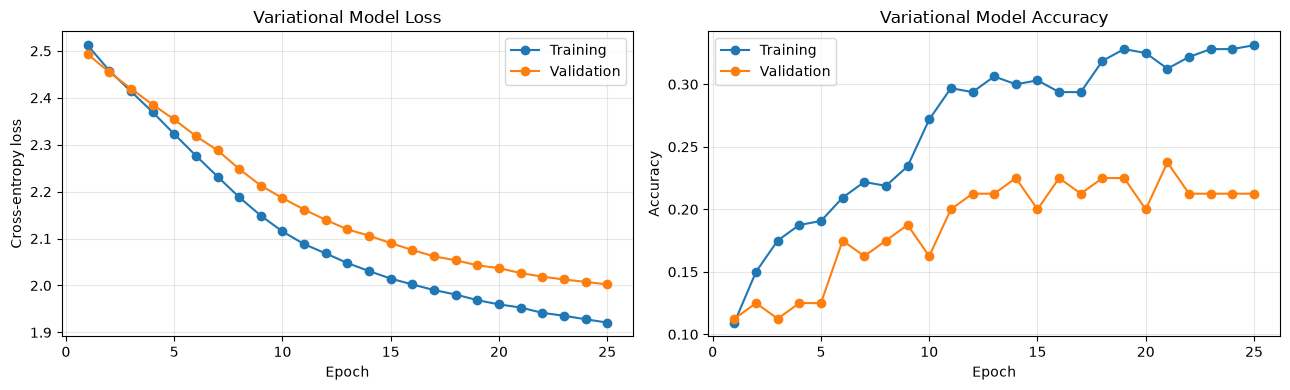

In [14]:
history_df = pd.DataFrame(training_history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training"
)
axes[0].plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation"
)
axes[0].set_title("Variational Model Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    marker="o",
    label="Training"
)
axes[1].plot(
    history_df["epoch"],
    history_df["validation_accuracy"],
    marker="o",
    label="Validation"
)
axes[1].set_title("Variational Model Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probabilities = torch.softmax(
        test_logits,
        dim=1
    ).cpu().numpy()

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

print("Test predictions:", test_predictions.shape)
print("Probability matrix:", test_probabilities.shape)

Test predictions: (100,)
Probability matrix: (100, 12)


In [16]:
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_predictions
)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        test_predictions,
        average="macro",
        zero_division=0
    )
)

weighted_precision, weighted_recall, weighted_f1, _ = (
    precision_recall_fscore_support(
        y_test,
        test_predictions,
        average="weighted",
        zero_division=0
    )
)

top_2_predictions = np.argsort(
    test_probabilities,
    axis=1
)[:, -2:]

top_3_predictions = np.argsort(
    test_probabilities,
    axis=1
)[:, -3:]

top_2_accuracy = np.mean([
    true_class in predicted_classes
    for true_class, predicted_classes
    in zip(y_test, top_2_predictions)
])

top_3_accuracy = np.mean([
    true_class in predicted_classes
    for true_class, predicted_classes
    in zip(y_test, top_3_predictions)
])

metrics_df = pd.DataFrame({
    "metric": [
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "top_2_accuracy",
        "top_3_accuracy",
        "training_seconds"
    ],
    "value": [
        test_accuracy,
        test_balanced_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_f1,
        top_2_accuracy,
        top_3_accuracy,
        training_seconds
    ]
})

display(metrics_df)

,metric,value
0,accuracy,0.250000
1,balanced_accuracy,0.237930
2,macro_precision,0.218117
3,macro_recall,0.237930
4,macro_f1,0.211216
5,weighted_f1,0.216943
6,top_2_accuracy,0.530000
7,top_3_accuracy,0.670000
8,training_seconds,20.742606


In [17]:
class_ids = sorted(np.unique(y_full_train))

classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        test_predictions,
        labels=class_ids,
        output_dict=True,
        zero_division=0
    )
).transpose()

display(classification_report_df)

,precision,recall,f1-score,support
0,0.000000,0.000000,0.000000,8.00
1,0.000000,0.000000,0.000000,7.00
2,0.437500,0.777778,0.560000,9.00
3,0.250000,0.125000,0.166667,8.00
4,0.129032,0.400000,0.195122,10.00
5,0.400000,0.250000,0.307692,8.00
6,0.333333,0.444444,0.380952,9.00
7,0.285714,0.222222,0.250000,9.00
8,0.000000,0.000000,0.000000,7.00
9,0.100000,0.100000,0.100000,10.00


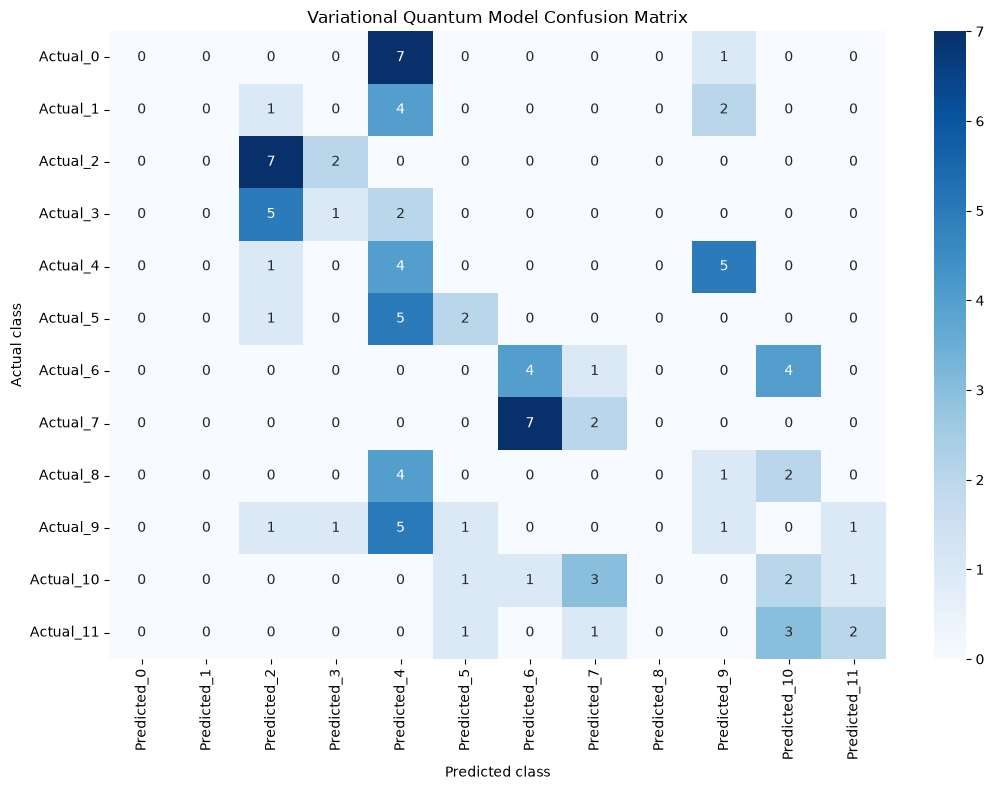

In [18]:
confusion = confusion_matrix(
    y_test,
    test_predictions,
    labels=class_ids
)

confusion_df = pd.DataFrame(
    confusion,
    index=[f"Actual_{value}" for value in class_ids],
    columns=[f"Predicted_{value}" for value in class_ids]
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    confusion_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Variational Quantum Model Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.show()

In [20]:
class_mapping.columns = (
    class_mapping.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Available Class_Mapping columns:")
print(class_mapping.columns.tolist())

display(class_mapping.head())

Available Class_Mapping columns:
['encoded_label', 'historical_medication_class']


,encoded_label,historical_medication_class
0,0,Acid-suppression class A
1,1,Acid-suppression class B
2,2,Antidiabetic class A
3,3,Antidiabetic class B
4,4,Antihistamine class A


In [21]:
encoded_candidates = [
    "encoded_target",
    "encoded_label",
    "class_id",
    "target_encoded",
    "label_encoded",
    "encoded_class"
]
medicine_candidates = [
    "historical_medication_class",
    "medication_class",
    "original_class",
    "class_name",
    "medicine_class",
    "target_class"
]

encoded_column = next(
    (
        column for column in encoded_candidates
        if column in class_mapping.columns
    ),
    None
)

medicine_column = next(
    (
        column for column in medicine_candidates
        if column in class_mapping.columns
    ),
    None
)

print("Detected encoded column:", encoded_column)
print("Detected medicine column:", medicine_column)

Detected encoded column: encoded_label
Detected medicine column: historical_medication_class


In [22]:
if encoded_column is not None and medicine_column is not None:
    mapping_dictionary = dict(
        zip(
            pd.to_numeric(
                class_mapping[encoded_column],
                errors="coerce"
            ).astype("Int64"),
            class_mapping[medicine_column].astype(str)
        )
    )
    mapping_dictionary = {
        int(key): value
        for key, value in mapping_dictionary.items()
        if pd.notna(key)
    }

else:
    print(
        "Required columns were not found in Class_Mapping.\n"
        "Creating the mapping from Y_Train instead."
    )

    if "historical_medication_class" not in y_train_df.columns:
        raise KeyError(
            "Neither Class_Mapping nor Y_Train contains the "
            "historical_medication_class column.\n"
            f"Class_Mapping columns: {class_mapping.columns.tolist()}\n"
            f"Y_Train columns: {y_train_df.columns.tolist()}"
        )

    mapping_dictionary = (
        y_train_df[
            ["encoded_target", "historical_medication_class"]
        ]
        .drop_duplicates()
        .set_index("encoded_target")[
            "historical_medication_class"
        ]
        .to_dict()
    )

    mapping_dictionary = {
        int(key): str(value)
        for key, value in mapping_dictionary.items()
    }

print("Number of mapped classes:", len(mapping_dictionary))
print(mapping_dictionary)

Number of mapped classes: 12
{0: 'Acid-suppression class A', 1: 'Acid-suppression class B', 2: 'Antidiabetic class A', 3: 'Antidiabetic class B', 4: 'Antihistamine class A', 5: 'Antihistamine class B', 6: 'Antihypertensive class A', 7: 'Antihypertensive class B', 8: 'Bronchodilator class', 9: 'Controller inhaler class', 10: 'Lipid-lowering class A', 11: 'Lipid-lowering class B'}


In [23]:
top_3_descending = np.argsort(
    test_probabilities,
    axis=1
)[:, -3:][:, ::-1]

prediction_results = pd.DataFrame({
    "actual_encoded_target": y_test,
    "predicted_encoded_target": test_predictions,

    "actual_medication_class": [
        mapping_dictionary.get(int(value), f"Class_{value}")
        for value in y_test
    ],

    "predicted_medication_class": [
        mapping_dictionary.get(int(value), f"Class_{value}")
        for value in test_predictions
    ],

    "prediction_confidence": np.max(
        test_probabilities,
        axis=1
    ),

    "prediction_correct": (
        y_test == test_predictions
    )
})

for position in range(3):
    predicted_class_ids = top_3_descending[:, position]

    prediction_results[
        f"top_{position + 1}_class"
    ] = [
        mapping_dictionary.get(
            int(class_id),
            f"Class_{class_id}"
        )
        for class_id in predicted_class_ids
    ]

    prediction_results[
        f"top_{position + 1}_probability"
    ] = [
        test_probabilities[row_number, class_id]
        for row_number, class_id in enumerate(
            predicted_class_ids
        )
    ]

display(prediction_results.head(10))

,actual_encoded_target,predicted_encoded_target,actual_medication_class,predicted_medication_class,prediction_confidence,prediction_correct,top_1_class,top_1_probability,top_2_class,top_2_probability,top_3_class,top_3_probability
0,9,4,Controller inhaler class,Antihistamine class A,0.160637,False,Antihistamine class A,0.160637,Acid-suppression class A,0.152142,Acid-suppression class B,0.129887
1,2,3,Antidiabetic class A,Antidiabetic class B,0.257730,False,Antidiabetic class B,0.257730,Antidiabetic class A,0.157873,Lipid-lowering class A,0.132992
2,10,10,Lipid-lowering class A,Lipid-lowering class A,0.304468,True,Lipid-lowering class A,0.304468,Lipid-lowering class B,0.279128,Antihistamine class B,0.108197
3,10,6,Lipid-lowering class A,Antihypertensive class A,0.383443,False,Antihypertensive class A,0.383443,Antihypertensive class B,0.333496,Lipid-lowering class A,0.090631
4,5,4,Antihistamine class B,Antihistamine class A,0.188603,False,Antihistamine class A,0.188603,Controller inhaler class,0.147896,Acid-suppression class A,0.128885
5,8,4,Bronchodilator class,Antihistamine class A,0.139274,False,Antihistamine class A,0.139274,Antihistamine class B,0.130103,Controller inhaler class,0.125971
6,7,6,Antihypertensive class B,Antihypertensive class A,0.261995,False,Antihypertensive class A,0.261995,Antihypertensive class B,0.247260,Antidiabetic class B,0.121743
7,3,4,Antidiabetic class B,Antihistamine class A,0.172820,False,Antihistamine class A,0.172820,Acid-suppression class A,0.155230,Acid-suppression class B,0.132319
8,5,5,Antihistamine class B,Antihistamine class B,0.129494,True,Antihistamine class B,0.129494,Controller inhaler class,0.111793,Lipid-lowering class A,0.108425
9,6,10,Antihypertensive class A,Lipid-lowering class A,0.443434,False,Lipid-lowering class A,0.443434,Lipid-lowering class B,0.293670,Antihistamine class B,0.061507


In [24]:
parameter_summary = []

for parameter_name, parameter in model.named_parameters():
    parameter_summary.append({
        "parameter": parameter_name,
        "shape": str(tuple(parameter.shape)),
        "trainable_values": parameter.numel()
    })

parameter_summary_df = pd.DataFrame(parameter_summary)

print(
    "Total trainable parameters:",
    parameter_summary_df["trainable_values"].sum()
)

display(parameter_summary_df)

Total trainable parameters: 84


,parameter,shape,trainable_values
0,quantum_layer.weights,"(2, 4, 3)",24
1,output_layer.weight,"(12, 4)",48
2,output_layer.bias,"(12,)",12


In [25]:
model_file = "variational_quantum_model_state.pt"
results_file = "variational_quantum_model_results.xlsx"
configuration_file = "variational_quantum_model_config.json"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "n_qubits": n_qubits,
        "n_classes": n_classes,
        "n_quantum_layers": n_quantum_layers,
        "weight_shapes": weight_shapes,
        "class_mapping": mapping_dictionary,
        "random_state": RANDOM_STATE
    },
    model_file
)

configuration = {
    "model_type": "Hybrid Variational Quantum Classifier",
    "input_file": input_file,
    "encoding": "AngleEmbedding-Y",
    "variational_template": "StronglyEntanglingLayers",
    "quantum_device": "default.qubit",
    "number_of_qubits": n_qubits,
    "number_of_quantum_layers": n_quantum_layers,
    "number_of_classes": n_classes,
    "batch_size": batch_size,
    "maximum_epochs": maximum_epochs,
    "epochs_completed": int(history_df["epoch"].max()),
    "learning_rate": 0.01,
    "best_validation_loss": float(best_validation_loss),
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(macro_f1),
    "random_state": RANDOM_STATE
}

with open(configuration_file, "w") as file:
    json.dump(configuration, file, indent=4)

with pd.ExcelWriter(
    results_file,
    engine="openpyxl"
) as writer:
    history_df.to_excel(
        writer,
        sheet_name="Training_History",
        index=False
    )

    metrics_df.to_excel(
        writer,
        sheet_name="Test_Metrics",
        index=False
    )

    classification_report_df.to_excel(
        writer,
        sheet_name="Classification_Report"
    )

    confusion_df.to_excel(
        writer,
        sheet_name="Confusion_Matrix"
    )

    prediction_results.to_excel(
        writer,
        sheet_name="Test_Predictions",
        index=False
    )

    parameter_summary_df.to_excel(
        writer,
        sheet_name="Model_Parameters",
        index=False
    )

    class_mapping.to_excel(
        writer,
        sheet_name="Class_Mapping",
        index=False
    )

    pd.DataFrame(
        list(configuration.items()),
        columns=["configuration", "value"]
    ).to_excel(
        writer,
        sheet_name="Configuration",
        index=False
    )

print("Saved model:", model_file)
print("Saved results:", results_file)
print("Saved configuration:", configuration_file)

Saved model: variational_quantum_model_state.pt
Saved results: variational_quantum_model_results.xlsx
Saved configuration: variational_quantum_model_config.json


In [26]:
required_output_files = [
    model_file,
    results_file,
    configuration_file
]

for output_file in required_output_files:
    print(
        output_file,
        "exists:",
        os.path.exists(output_file)
    )

print("\nFinal test accuracy:", round(test_accuracy, 4))
print("Final macro F1:", round(macro_f1, 4))
print("Final top-3 accuracy:", round(top_3_accuracy, 4))

variational_quantum_model_state.pt exists: True
variational_quantum_model_results.xlsx exists: True
variational_quantum_model_config.json exists: True

Final test accuracy: 0.25
Final macro F1: 0.2112
Final top-3 accuracy: 0.67
